# 切分参数调优：复合手势（sc）的处理

## 背景

在预处理流水线的初始运行中，`sc`（剪刀手）手势的部分文件切分结果为零。
本 Notebook 分析问题根因，记录参数调整过程和验证结果，
作为信号处理参数调优的案例文档。

## 核心发现

`sc` 是一个 **复合手势**——做一次剪刀手动作时，手指的开合会在单个通道上产生 2-3 个子脉冲（sub-burst），
间隔约 100-150ms。这与其他手势（如 stop、wave）的单脉冲模式不同。

原始参数 `merge_gap_s=0.050`（50ms）设计用于合并因传感器抖动产生的碎片信号，
但 50ms 远小于 sc 手势的子脉冲间隔（100-150ms），
导致这些子脉冲被识别为同一动作窗口内的多次独立激活，触发纯净度自检而被全部丢弃。

**解决方案**：将 `merge_gap_s` 从 0.050 调整到 0.200（200ms），
使同一手势的子脉冲能被正确合并为一个整体激活段。

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess.io import load_raw_csv
from src.preprocess.segmenter import SegParams, segment_file, analyze_single_channel, detect_joint_actions
from src.preprocess.cleaner import clean_segment, build_filters
from src.preprocess.features import calculate_9d_vector, FEATURE_NAMES

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

FS = 1000
CH_NAMES = ['CH1', 'CH3', 'CH5']
CH_COLORS = ['#2196F3', '#4CAF50', '#FF9800']

sc1_path = PROJECT_ROOT / 'data' / 'raw' / 'base' / 'sc-1.csv'
signal = load_raw_csv(sc1_path)
time_s = np.arange(len(signal)) / FS
print(f'sc-1.csv: {signal.shape[0]} samples ({time_s[-1]:.1f}s), expected ~20 gestures')

sc-1.csv: 64768 samples (64.8s), expected ~20 gestures


---
## 1. sc 手势的信号特征

先观察 sc-1.csv 的原始波形，理解复合手势的信号结构。

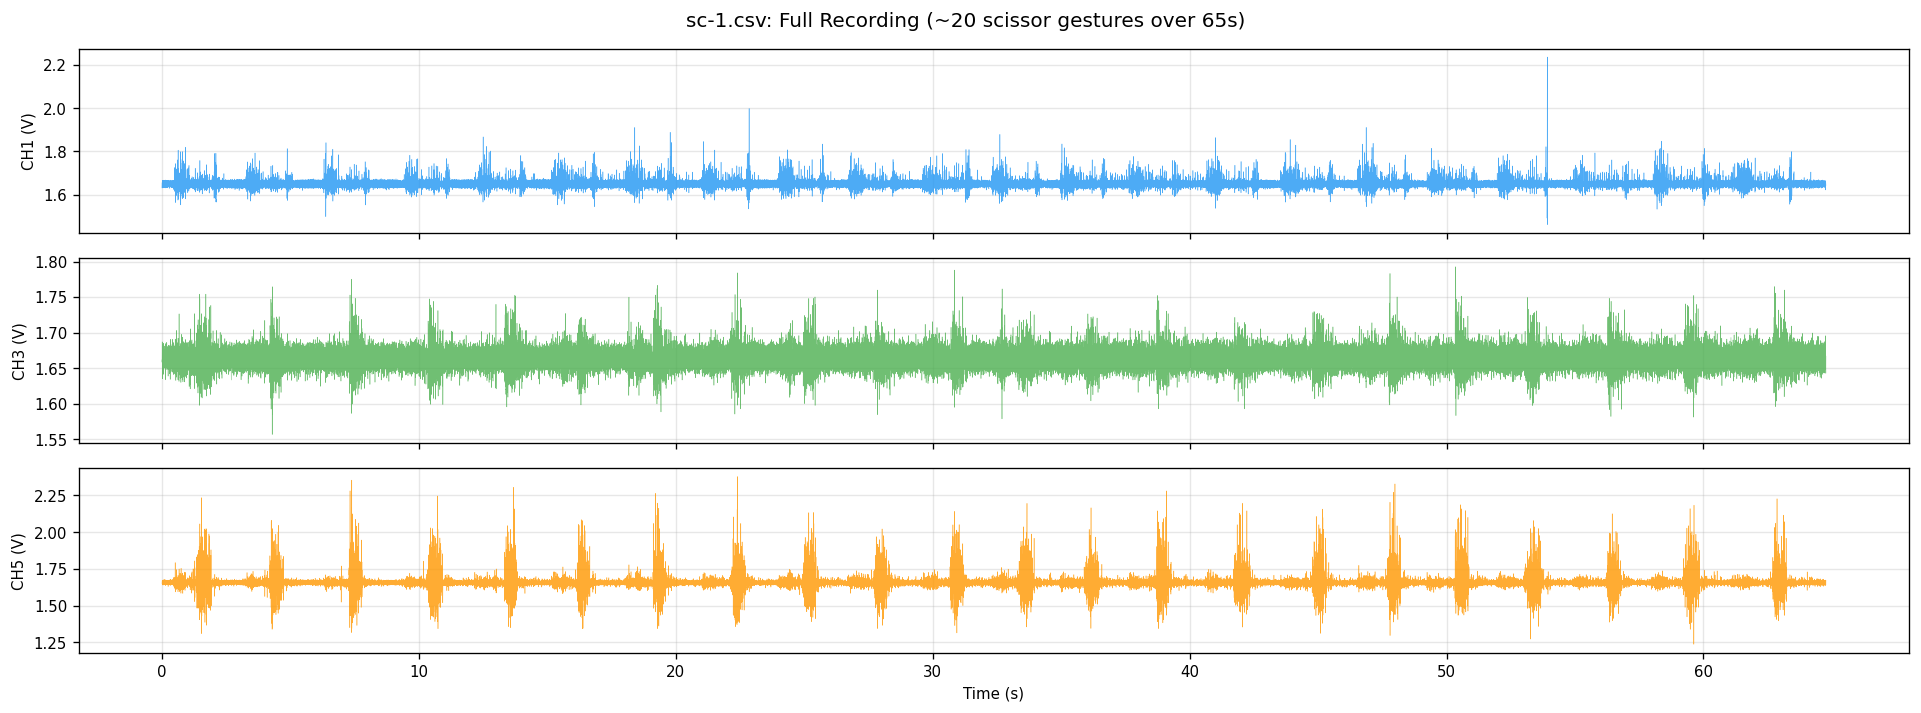

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(16, 6), sharex=True)
for i, (ax, name, color) in enumerate(zip(axes, CH_NAMES, CH_COLORS)):
    ax.plot(time_s, signal[:, i], color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(f'{name} (V)')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('sc-1.csv: Full Recording (~20 scissor gestures over 65s)', fontsize=12)
plt.tight_layout()
plt.show()

### 信号特点

`sc` 手势的三通道波形呈现出明显的周期性结构，每约 3 秒一次动作。
与 stop 等简单手势不同，每次 sc 动作在信号上呈现出 **双峰或多峰结构**，
这是因为剪刀手需要手指先张开再合拢（或反复开合），每次开合都产生一次电压脉冲。

下面放大一个动作区间，仔细观察这种子脉冲结构。

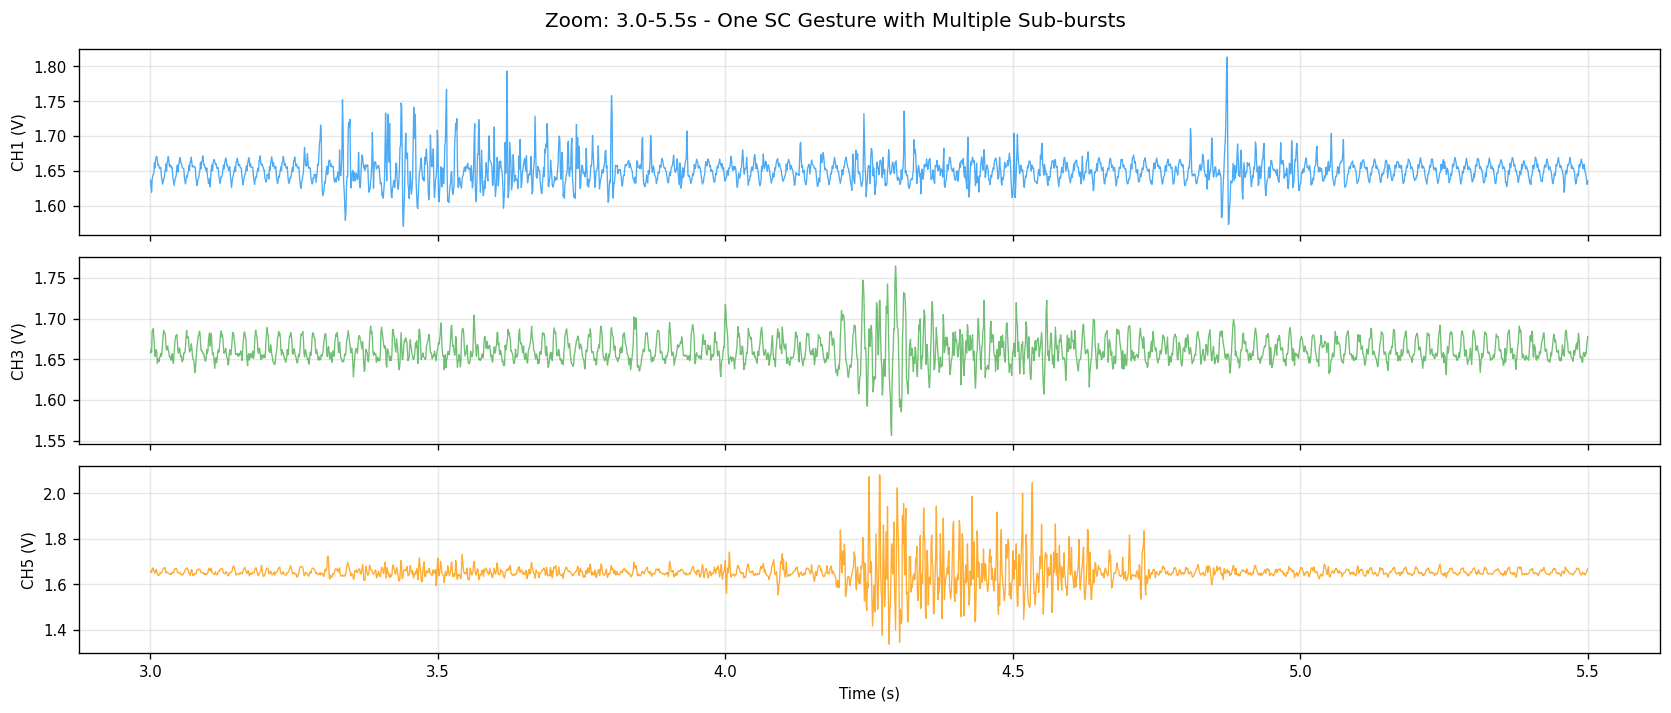

In [3]:
# Zoom into 3.0-5.5s to show sub-burst structure
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
t_start, t_end = 3.0, 5.5
mask = (time_s >= t_start) & (time_s <= t_end)

for i, (ax, name, color) in enumerate(zip(axes, CH_NAMES, CH_COLORS)):
    ax.plot(time_s[mask], signal[mask, i], color=color, linewidth=0.8, alpha=0.8)
    ax.set_ylabel(f'{name} (V)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Zoom: 3.0-5.5s - One SC Gesture with Multiple Sub-bursts', fontsize=12)
plt.tight_layout()
plt.show()

### 关键观察

在 3.0-5.5 秒区间内可以看到一次 sc 手势的完整波形：
- **CH1**（蓝色）出现 2-3 个独立的脉冲峰值，间隔约 100-150ms
- **CH5**（橙色）响应最强，但也显示出类似的多峰结构
- 这些子脉冲在物理上是同一次手势动作，但在信号上表现为多个分离的激活段

这就是问题的核心：如果合并间隔（merge_gap）设置太小，这些子脉冲会被识别为独立的激活事件。

---
## 2. 参数对比：merge_gap = 50ms vs 200ms

### merge_gap 的作用

`merge_gap_s` 控制单通道内相邻激活段的合并行为：
- 如果两个激活段之间的间隔小于 merge_gap，则合并为一个
- 设置太小：同一动作的子脉冲不会合并，被误判为多次发力
- 设置太大：可能把相邻的两次不同动作错误合并

下面对比两种参数下的激活段检测结果。

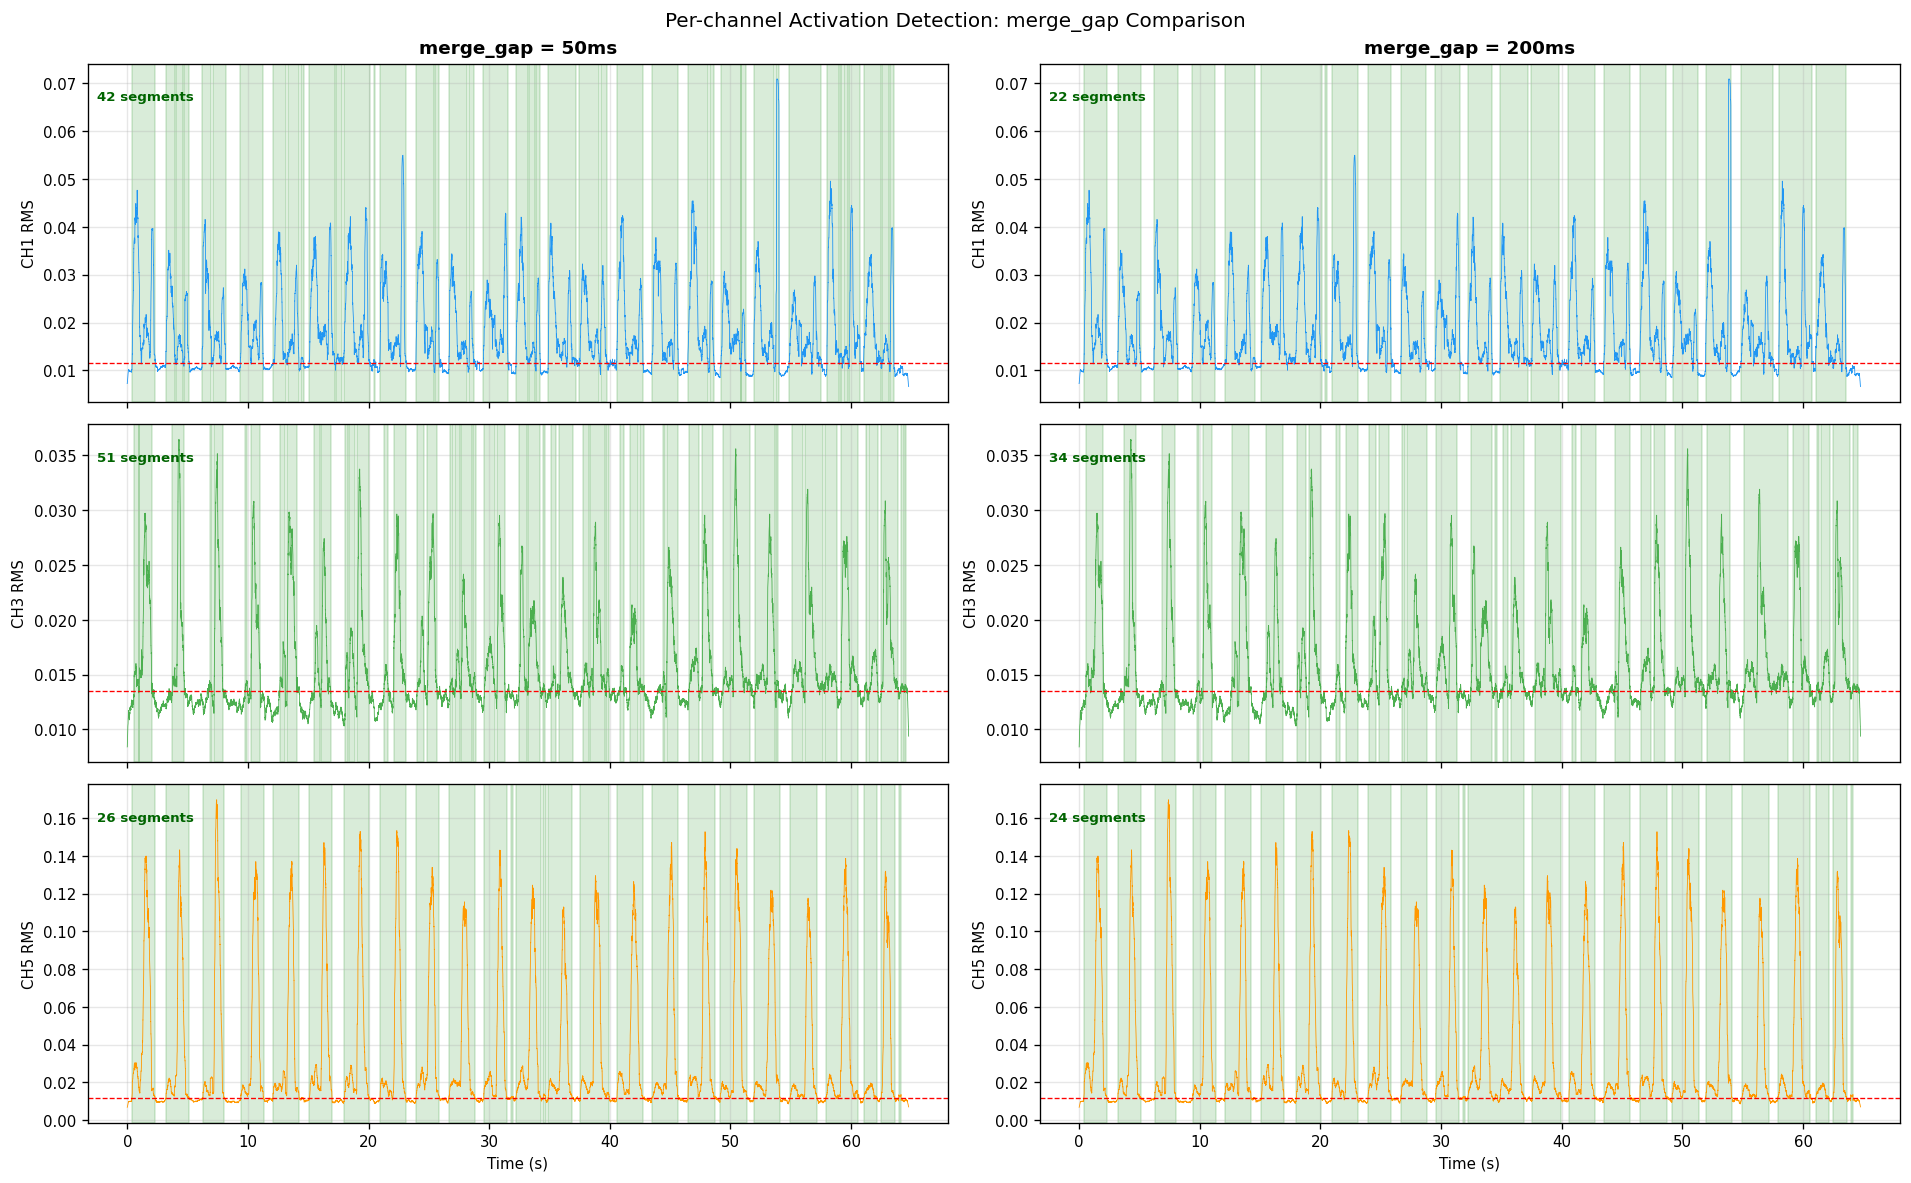

Activation segment counts:
  CH1: 42 (50ms) -> 22 (200ms)
  CH3: 51 (50ms) -> 34 (200ms)
  CH5: 26 (50ms) -> 24 (200ms)


In [4]:
params_50 = SegParams(fs=FS, merge_gap_s=0.050)
params_200 = SegParams(fs=FS, merge_gap_s=0.200)

analyses_50 = [analyze_single_channel(signal[:, ch], params_50) for ch in range(3)]
analyses_200 = [analyze_single_channel(signal[:, ch], params_200) for ch in range(3)]

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')

for i, (name, color) in enumerate(zip(CH_NAMES, CH_COLORS)):
    for j, (analysis, gap_label) in enumerate([(analyses_50[i], '50ms'), (analyses_200[i], '200ms')]):
        ax = axes[i, j]
        ax.plot(time_s, analysis['rms_env'], color=color, linewidth=0.5)
        ax.axhline(analysis['threshold'], color='red', linestyle='--', linewidth=0.8)
        for a, b in analysis['active_segments']:
            ax.axvspan(a/FS, b/FS, alpha=0.15, color='green')
        ax.set_ylabel(f'{name} RMS')
        ax.grid(True, alpha=0.3)
        n = len(analysis['active_segments'])
        ax.text(0.01, 0.92, f'{n} segments', transform=ax.transAxes,
                fontsize=8, va='top', color='darkgreen', fontweight='bold')
        if i == 0:
            ax.set_title(f'merge_gap = {gap_label}', fontsize=11, fontweight='bold')

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
fig.suptitle('Per-channel Activation Detection: merge_gap Comparison', fontsize=12)
plt.tight_layout()
plt.show()

print('Activation segment counts:')
for i, name in enumerate(CH_NAMES):
    n50 = len(analyses_50[i]['active_segments'])
    n200 = len(analyses_200[i]['active_segments'])
    print(f'  {name}: {n50} (50ms) -> {n200} (200ms)')

### 如何读这张图

左列和右列分别对应 merge_gap=50ms 和 200ms 的结果：

- **绿色色块**：检测到的激活段
- **左列（50ms）**：CH1 检测到 42 个碎片化的激活段——同一次手势被拆成多个短段
- **右列（200ms）**：激活段数量大幅减少，子脉冲被正确合并为完整的动作段

关键差异在 CH1：50ms 时每次 sc 动作被拆成 2-3 段，200ms 时被合并为 1 段。
而在 CH5 上差异较小，因为 CH5 的响应更强，子脉冲之间的间隔信号仍然超过阈值。

---
## 3. 对联合动作检测的影响

单通道激活段的碎片化会直接影响联合动作检测的纯净度自检。

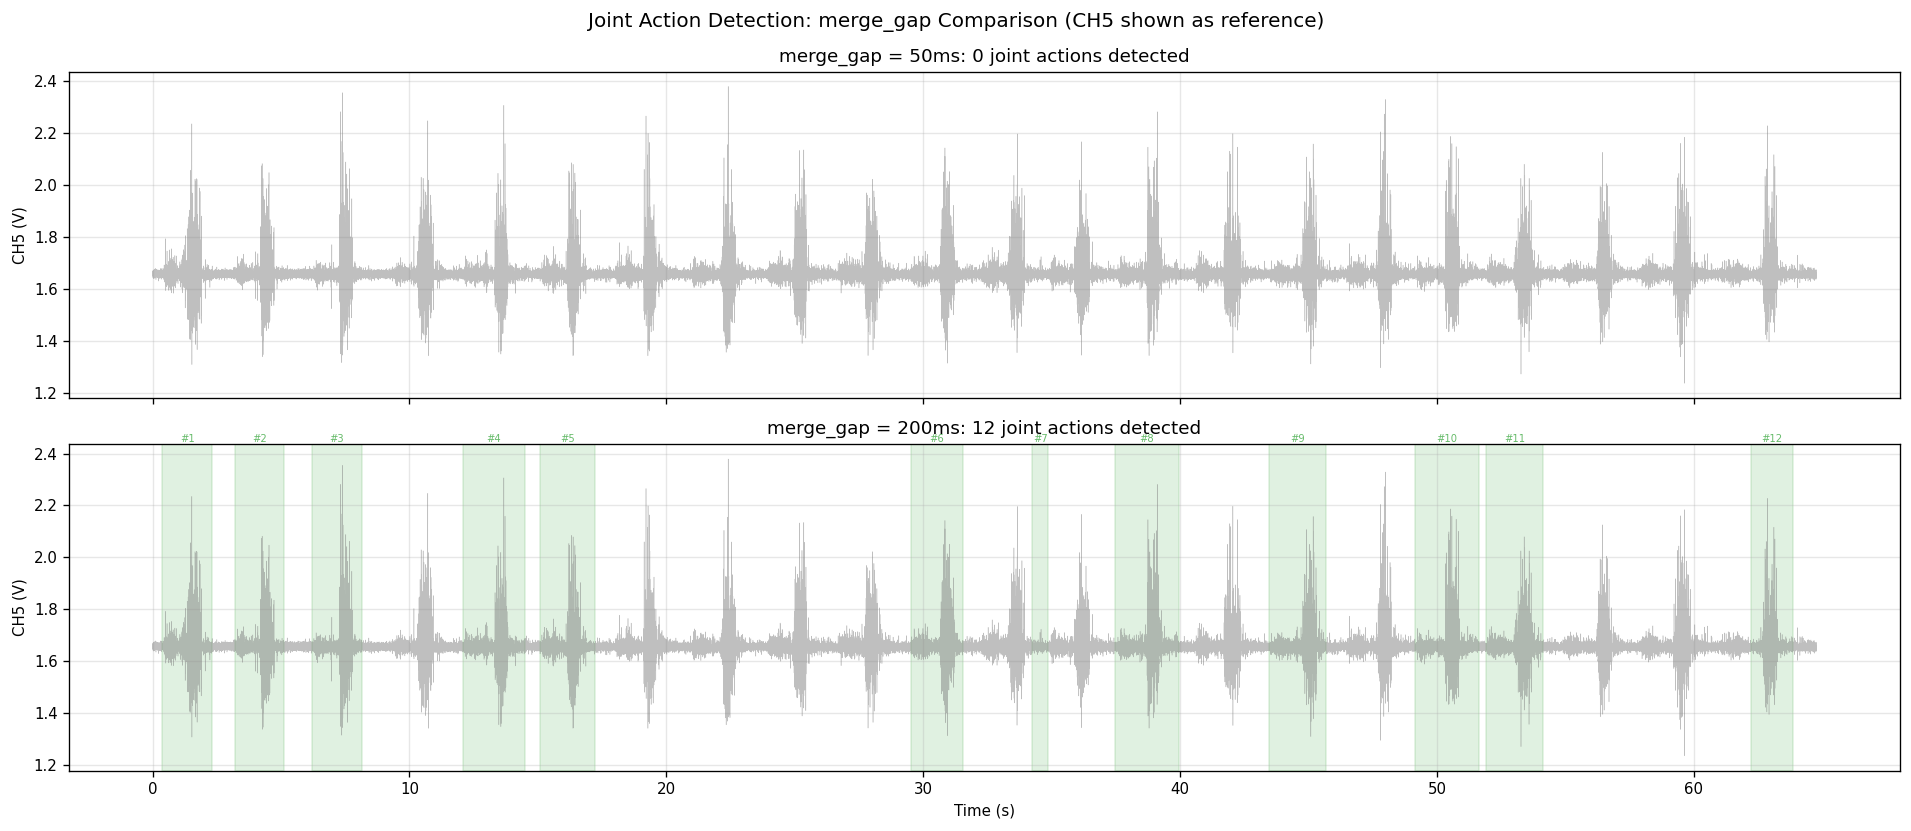

In [5]:
joints_50 = detect_joint_actions(signal, params_50)
joints_200 = detect_joint_actions(signal, params_200)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax, joints, gap_label, color in [
    (axes[0], joints_50, '50ms', '#EF5350'),
    (axes[1], joints_200, '200ms', '#66BB6A'),
]:
    ax.plot(time_s, signal[:, 2], color='gray', linewidth=0.3, alpha=0.5)  # CH5
    for idx, (a, b) in enumerate(joints):
        ax.axvspan(a/FS, b/FS, alpha=0.2, color=color)
        mid = (a + b) / 2 / FS
        ylim = ax.get_ylim()
        ax.text(mid, ylim[1], f'#{idx+1}', ha='center', fontsize=6, color=color, va='bottom')
    ax.set_ylabel('CH5 (V)')
    ax.set_title(f'merge_gap = {gap_label}: {len(joints)} joint actions detected', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Joint Action Detection: merge_gap Comparison (CH5 shown as reference)', fontsize=12)
plt.tight_layout()
plt.show()

### 结果对比

| 参数 | 检测到的联合动作数 | 说明 |
|------|-------------------|------|
| merge_gap = 50ms | **0** | 全部被纯净度自检拒绝 |
| merge_gap = 200ms | **12** | 成功检测到 12 个干净动作 |

- **50ms**（上图）：每个联合动作窗口内，CH1 都包含 2-3 个独立激活段，
  纯净度自检认为存在多次发力，全部丢弃。结果：零有效样本。
- **200ms**（下图）：子脉冲被正确合并后，每个窗口内每通道只有 1 个激活段，
  通过纯净度自检。文件约 20 次手势，最终检测到 12 个干净样本（其余因边界重叠或信号不完整被过滤）。

---
## 4. 修复后的清洗效果

确认切出的片段经过信号清洗后质量良好。

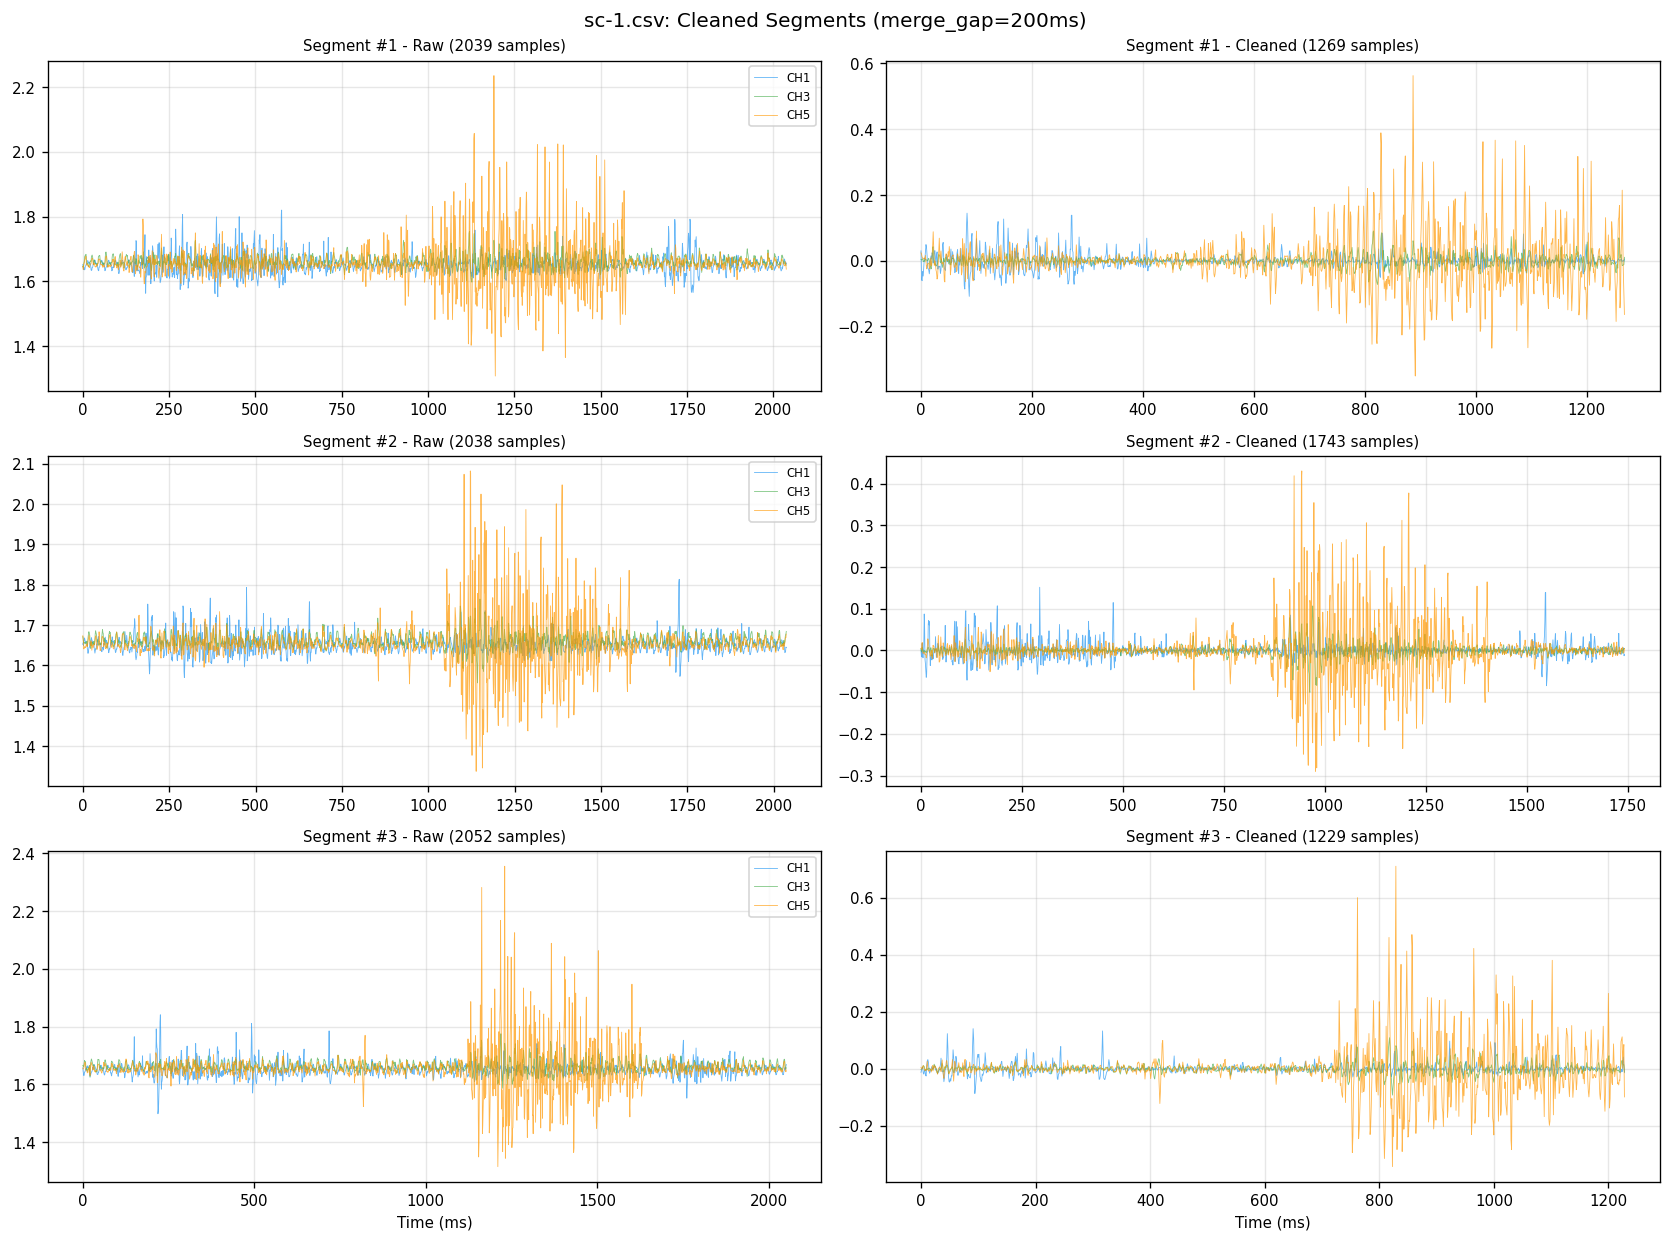

In [6]:
segments = segment_file(signal, params_200)
filters = build_filters(FS)
n_show = min(3, len(segments))

fig, axes = plt.subplots(n_show, 2, figsize=(14, 3.5 * n_show), squeeze=False)

for seg_idx in range(n_show):
    raw_seg = segments[seg_idx]
    cleaned_seg = clean_segment(raw_seg, fs=FS, filters=filters)
    t_raw = np.arange(len(raw_seg)) / FS * 1000
    t_clean = np.arange(len(cleaned_seg)) / FS * 1000

    for ch in range(3):
        axes[seg_idx, 0].plot(t_raw, raw_seg[:, ch], color=CH_COLORS[ch],
                              linewidth=0.5, alpha=0.7, label=CH_NAMES[ch])
        axes[seg_idx, 1].plot(t_clean, cleaned_seg[:, ch], color=CH_COLORS[ch],
                              linewidth=0.5, alpha=0.7, label=CH_NAMES[ch])

    axes[seg_idx, 0].set_title(f'Segment #{seg_idx+1} - Raw ({raw_seg.shape[0]} samples)', fontsize=9)
    axes[seg_idx, 1].set_title(f'Segment #{seg_idx+1} - Cleaned ({cleaned_seg.shape[0]} samples)', fontsize=9)
    axes[seg_idx, 0].legend(fontsize=7, loc='upper right')
    axes[seg_idx, 0].grid(True, alpha=0.3)
    axes[seg_idx, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (ms)')

fig.suptitle('sc-1.csv: Cleaned Segments (merge_gap=200ms)', fontsize=12)
plt.tight_layout()
plt.show()

### 清洗结果说明

- **左列**：切出的原始片段，包含完整的 sc 手势波形（多峰结构）
- **右列**：清洗后的片段，去除了直流偏置和高/低频噪声，保留了手势信号的核心特征

每个片段时长约 1500-2500ms，包含了完整的剪刀手动作过程。
清洗后的信号以零为中心，CH5（橙色）通常响应最强，符合传感器的物理布局。

---
## 5. 全数据集影响评估

参数调整不仅影响 sc 手势，还会影响其他手势的切分结果。
需要验证 merge_gap 从 50ms 提升到 200ms 后，其他手势的样本数不会异常减少。

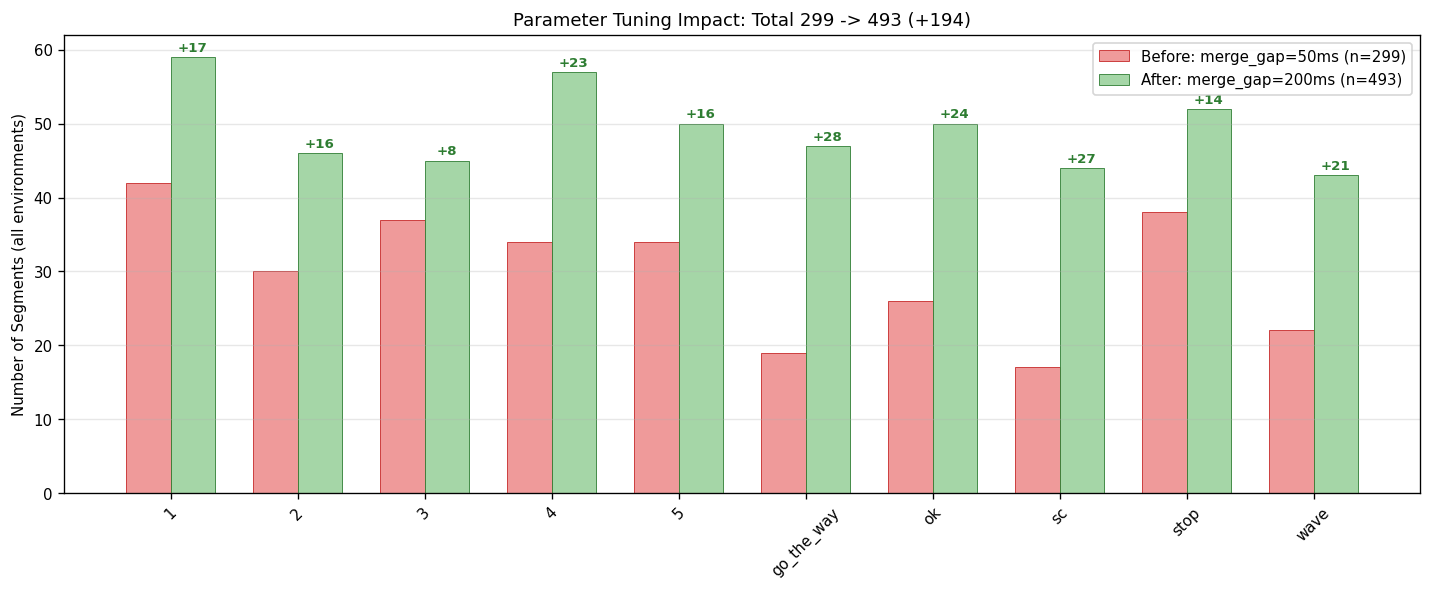

In [7]:
before = {
    '1': 42, '2': 30, '3': 37, '4': 34, '5': 34,
    'go_the_way': 19, 'ok': 26, 'sc': 17, 'stop': 38, 'wave': 22
}
total_before = sum(before.values())

stats_path = PROJECT_ROOT / 'data' / 'processed' / 'stats' / 'segment_counts.csv'
after_df = pd.read_csv(stats_path, index_col=0)
after = after_df['total'].to_dict()
total_after = sum(after.values())

gestures = list(before.keys())
x = np.arange(len(gestures))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, [before[g] for g in gestures], w, label=f'Before: merge_gap=50ms (n={total_before})',
       color='#EF9A9A', edgecolor='#C62828', linewidth=0.5)
ax.bar(x + w/2, [after[g] for g in gestures], w, label=f'After: merge_gap=200ms (n={total_after})',
       color='#A5D6A7', edgecolor='#2E7D32', linewidth=0.5)

for i, g in enumerate(gestures):
    diff = after[g] - before[g]
    if diff != 0:
        color = '#2E7D32' if diff > 0 else '#C62828'
        sign = '+' if diff > 0 else ''
        ax.text(i + w/2, after[g] + 0.8, f'{sign}{diff}', ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(gestures, rotation=45)
ax.set_ylabel('Number of Segments (all environments)')
ax.set_title(f'Parameter Tuning Impact: Total {total_before} -> {total_after} (+{total_after - total_before})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 结果分析

参数调整后 **所有手势的样本数均有增加**：

- **sc**（剪刀手）：增幅最大，从 17 增加到 44（+27），核心问题解决
- **其他手势**：也有不同程度的增加，因为更大的 merge_gap 将更多原本被碎片化的动作正确合并
- **总样本数**：299 → 493（+194，增加 65%）
- **没有任何手势出现样本数下降**，说明参数调整没有引入副作用

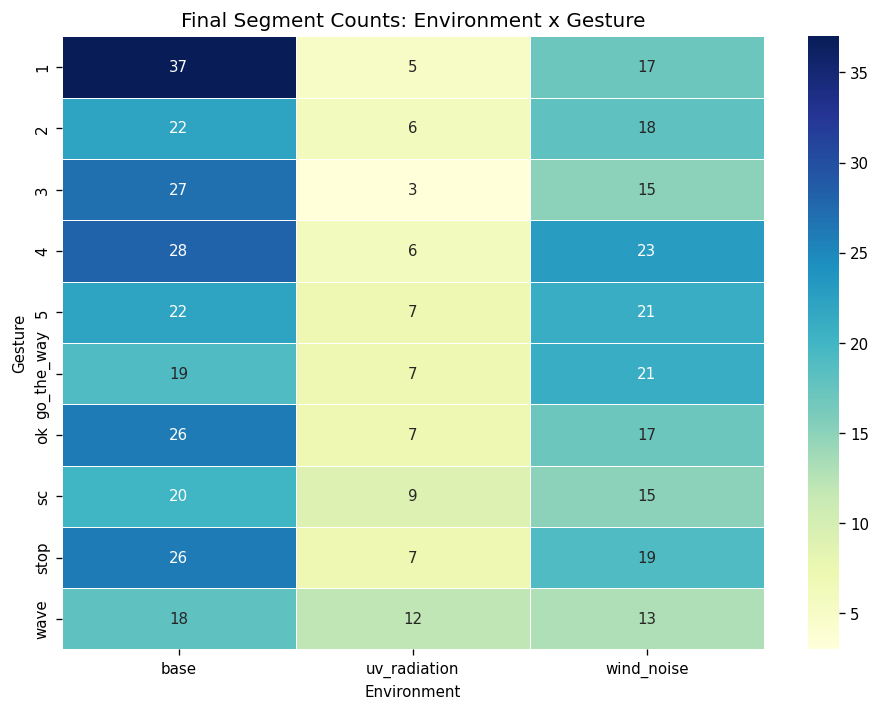

Total segments: 493

Per-environment totals:
  base: 245
  uv_radiation: 69
  wind_noise: 179


In [8]:
# Heatmap of final segment counts
plot_cols = [c for c in after_df.columns if c != 'total']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(after_df[plot_cols], annot=True, fmt='d', cmap='YlGnBu', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Final Segment Counts: Environment x Gesture', fontsize=12)
ax.set_ylabel('Gesture')
ax.set_xlabel('Environment')
plt.tight_layout()
plt.show()

print(f'Total segments: {after_df["total"].sum()}')
print(f'\nPer-environment totals:')
for col in plot_cols:
    print(f'  {col}: {after_df[col].sum()}')

### 如何读这张热力图

- **颜色深浅**：数值越大颜色越深，直观反映各类别的样本量
- **行**：10 种手势
- **列**：3 种环境

关注点：
- base 环境样本最多（合并了两批次数据）
- uv_radiation 环境样本较少（每文件仅约 5 次动作），但每个手势仍有 3-12 个样本
- 类别间大致均衡，最少的 `3/uv_radiation` 只有 3 个样本，需要注意

---
## 总结

| 项目 | 调整前 | 调整后 |
|------|--------|--------|
| merge_gap_s | 0.050 (50ms) | 0.200 (200ms) |
| sc 手势有效样本 | 17 | 44 |
| 全数据集有效样本 | 299 | 493 |
| 其他手势影响 | - | 全部增加，无副作用 |

**参数调优经验：**
1. 当某类信号的切分结果异常时，应先检查该信号的时域波形结构，理解其物理特性
2. 复合手势（涉及多次开合动作）的子脉冲间隔通常在 100-200ms，merge_gap 需要覆盖这个范围
3. 调参后必须验证对其他类别的影响，确保无副作用